# 02 — Exploratory Analysis

This notebook explores the **structure-resolved DILIrank 2.0 dataset** produced by `01_data_preparation.ipynb`.

## Goals
- summarize the 1,215 structure-resolved compounds;
- inspect `vDILI-Concern` and `SeverityClass`;
- explore simple interpretable molecular properties;
- characterize scaffold diversity;
- examine structural similarity;
- visualize chemical space;
- inspect where Ambiguous compounds lie.

## Scope
This notebook is descriptive only. It does **not** remove Ambiguous compounds, generate the formal modelling feature matrices, create train/test splits, or fit predictive models.


## 1. Imports and configuration

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, Lipinski, Crippen, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdFingerprintGenerator

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

DATA_PATH = Path("data/processed/dilirank2_structures.csv")
FIGURE_DIR = Path("results/figures/eda")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input dataset: {DATA_PATH}")
print(f"Figure directory: {FIGURE_DIR}")


Input dataset: data/processed/dilirank2_structures.csv
Figure directory: results/figures/eda


In [3]:
data = pd.read_csv(DATA_PATH)

print(f"Rows: {len(data):,}")
print(f"Columns: {data.shape[1]:,}")
display(data.head())


Rows: 1,215
Columns: 26


,LTKBID,CompoundName,SeverityClass,LabelSection,vDILI-Concern,Comment,PubChemCID,PubChemTitle,pubchem_status,rdkit_valid,SMILES_raw,InChIKey_raw,SMILES_rdkit,n_fragments,standardization_ok,standardization_error,SMILES_standardized,InChIKey_standardized,SMILES_parent,InChIKey_parent,standardized_group_size,parent_group_size,has_standardized_duplicate,has_parent_duplicate,standardized_label_conflict,parent_label_conflict
0,LT00040,Abacavir sulfate,8,Warnings & precautions,vMost-DILI-concern,Unchanged,441384.0,Abacavir Sulfate,found,True,C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)[C@@H]4C[C@@H](C=C4)CO.C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)[C@@H]4C[C@@H](C=C4)CO.OS(=O)(=O)O,WMHSRBZIJNQHKT-FFKFEZPRSA-N,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1.Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1.O=S(=O)(O)O,3,True,NaN,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1.Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1.O=S(=O)(O)O,WMHSRBZIJNQHKT-FFKFEZPRSA-N,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,MCGSCOLBFJQGHM-SCZZXKLOSA-N,1,1,False,False,False,False
1,LT03618,Abaloparatide,0,No match,vNo-DILI-concern,New,76943386.0,Abaloparatide,found,True,CC[C@H](C)[C@@H](C(=O)N[C@@H](CCC(=O)N)C(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CCCNC(=N)N)C(=O)N[C@@H]...,BVISQZFBLRSESR-XSCWXTNMSA-N,CC[C@H](C)[C@H](NC(=O)[C@H](CO)NC(=O)[C@H](CCCCN)NC(=O)CNC(=O)[C@H](CCCCN)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](Cc1cnc[nH]...,1,True,NaN,CC[C@H](C)[C@H](NC(=O)[C@H](CO)NC(=O)[C@H](CCCCN)NC(=O)CNC(=O)[C@H](CCCCN)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](Cc1cnc[nH]...,BVISQZFBLRSESR-XSCWXTNMSA-N,CC[C@H](C)[C@H](NC(=O)[C@H](CO)NC(=O)[C@H](CCCCN)NC(=O)CNC(=O)[C@H](CCCCN)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](Cc1cnc[nH]...,BVISQZFBLRSESR-XSCWXTNMSA-N,1,1,False,False,False,False
2,LT03619,Abemaciclib,3,Warnings & precautions,vLess-DILI-concern,New,46220502.0,Abemaciclib,found,True,CCN1CCN(CC1)CC2=CN=C(C=C2)NC3=NC=C(C(=N3)C4=CC5=C(C(=C4)F)N=C(N5C(C)C)C)F,UZWDCWONPYILKI-UHFFFAOYSA-N,CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc(C)n(C(C)C)c5c4)n3)nc2)CC1,1,True,NaN,CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc(C)n(C(C)C)c5c4)n3)nc2)CC1,UZWDCWONPYILKI-UHFFFAOYSA-N,CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc(C)n(C(C)C)c5c4)n3)nc2)CC1,UZWDCWONPYILKI-UHFFFAOYSA-N,1,1,False,False,False,False
3,LT02339,Abiraterone acetate,8,Warnings & precautions,vMost-DILI-concern,New,9821849.0,Abiraterone Acetate,found,True,CC(=O)O[C@H]1CC[C@@]2([C@H]3CC[C@]4([C@H]([C@@H]3CC=C2C1)CC=C4C5=CN=CC=C5)C)C,UVIQSJCZCSLXRZ-UBUQANBQSA-N,CC(=O)O[C@H]1CC[C@@]2(C)C(=CC[C@@H]3[C@@H]2CC[C@]2(C)C(c4cccnc4)=CC[C@@H]32)C1,1,True,NaN,CC(=O)O[C@H]1CC[C@@]2(C)C(=CC[C@@H]3[C@@H]2CC[C@]2(C)C(c4cccnc4)=CC[C@@H]32)C1,UVIQSJCZCSLXRZ-UBUQANBQSA-N,CC(=O)O[C@H]1CC[C@@]2(C)C(=CC[C@@H]3[C@@H]2CC[C@]2(C)C(c4cccnc4)=CC[C@@H]32)C1,UVIQSJCZCSLXRZ-UBUQANBQSA-N,1,1,False,False,False,False
4,LT03614,Acalabrutinib,4,Adverse reactions,Ambiguous-DILI-concern,New,71226662.0,Acalabrutinib,found,True,CC#CC(=O)N1CCC[C@H]1C2=NC(=C3N2C=CN=C3N)C4=CC=C(C=C4)C(=O)NC5=CC=CC=N5,WDENQIQQYWYTPO-IBGZPJMESA-N,CC#CC(=O)N1CCC[C@H]1c1nc(-c2ccc(C(=O)Nc3ccccn3)cc2)c2c(N)nccn12,1,True,NaN,CC#CC(=O)N1CCC[C@H]1c1nc(-c2ccc(C(=O)Nc3ccccn3)cc2)c2c(N)nccn12,WDENQIQQYWYTPO-IBGZPJMESA-N,CC#CC(=O)N1CCC[C@H]1c1nc(-c2ccc(C(=O)Nc3ccccn3)cc2)c2c(N)nccn12,WDENQIQQYWYTPO-IBGZPJMESA-N,1,1,False,False,False,False


In [4]:
required_columns = {
    "LTKBID",
    "CompoundName",
    "vDILI-Concern",
    "SeverityClass",
    "SMILES_standardized",
    "SMILES_parent",
    "InChIKey_standardized",
    "InChIKey_parent",
    "n_fragments",
}

missing = required_columns - set(data.columns)

if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

print("Required columns present.")


Required columns present.


## 2. Dataset overview

Notebook 01 already handled the detailed data-quality audit. Here we keep the overview brief and focus on the structure-resolved dataset.


In [5]:
overview = pd.Series({
    "Compounds": len(data),
    "Unique LTKBID": data["LTKBID"].nunique(),
    "Unique standardized structures": data["InChIKey_standardized"].nunique(dropna=True),
    "Unique parent structures": data["InChIKey_parent"].nunique(dropna=True),
    "Multi-fragment compounds": int((data["n_fragments"].fillna(0) > 1).sum()),
    "Missing standardized SMILES": int(data["SMILES_standardized"].isna().sum()),
}, name="count")

display(overview.to_frame())


,count
Compounds,1215
Unique LTKBID,1215
Unique standardized structures,1214
Unique parent structures,1204
Multi-fragment compounds,560
Missing standardized SMILES,0


## 3. DILI-concern distribution

In [6]:
concern_counts = (
    data["vDILI-Concern"]
    .value_counts(dropna=False)
    .rename_axis("vDILI-Concern")
    .to_frame("count")
)

concern_counts["percentage"] = 100 * concern_counts["count"] / concern_counts["count"].sum()
display(concern_counts)


,count,percentage
vDILI-Concern,,
vNo-DILI-concern,350,28.806584
vLess-DILI-concern,330,27.160494
Ambiguous-DILI-concern,329,27.078189
vMost-DILI-concern,206,16.954733


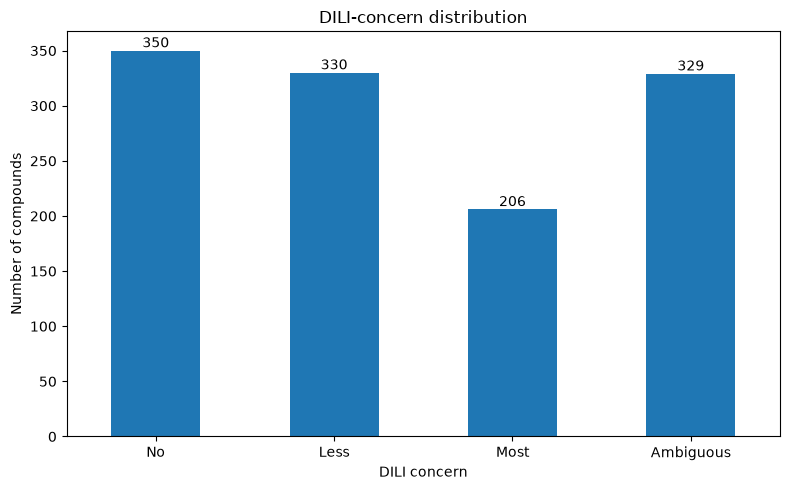

In [7]:
CONCERN_NAME_MAP = {
    "vNo-DILI-concern": "No",
    "vLess-DILI-concern": "Less",
    "vMost-DILI-concern": "Most",
    "Ambiguous-DILI-concern": "Ambiguous",
}

data["ConcernDisplay"] = (
    data["vDILI-Concern"]
    .map(CONCERN_NAME_MAP)
    .fillna(data["vDILI-Concern"])
)

preferred_order = ["No", "Less", "Most", "Ambiguous"]
concern_order = [x for x in preferred_order if x in set(data["ConcernDisplay"].dropna())]
concern_order += [x for x in data["ConcernDisplay"].dropna().unique() if x not in concern_order]

plot_counts = data["ConcernDisplay"].value_counts().reindex(concern_order)

fig, ax = plt.subplots(figsize=(8, 5))
plot_counts.plot(kind="bar", ax=ax)
ax.set_title("DILI-concern distribution")
ax.set_xlabel("DILI concern")
ax.set_ylabel("Number of compounds")
ax.tick_params(axis="x", rotation=0)

for i, value in enumerate(plot_counts.values):
    ax.text(i, value, str(int(value)), ha="center", va="bottom")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "dili_concern_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. DILI concern and SeverityClass

`vDILI-Concern` is the endpoint planned for the main benchmark. `SeverityClass` is explored here as a separate DILIrank 2.0 field.

This section is descriptive only; `SeverityClass` is not used as a predictor.


In [8]:
severity_counts = (
    data["SeverityClass"]
    .value_counts(dropna=False)
    .rename_axis("SeverityClass")
    .to_frame("count")
)

severity_counts["percentage"] = 100 * severity_counts["count"] / severity_counts["count"].sum()
display(severity_counts)


,count,percentage
SeverityClass,,
0,394,32.427984
3,375,30.864198
8,171,14.074074
4,91,7.489712
5,69,5.679012
7,60,4.938272
2,46,3.786008
6,6,0.493827
1,3,0.246914


In [9]:
concern_severity = pd.crosstab(
    data["ConcernDisplay"],
    data["SeverityClass"],
    dropna=False,
)

concern_severity = concern_severity.reindex(
    [x for x in concern_order if x in concern_severity.index]
)

display(concern_severity)


SeverityClass,0,1,2,3,4,5,6,7,8
ConcernDisplay,,,,,,,,,
No,349,1,0,0,0,0,0,0,0
Less,44,0,24,166,34,32,1,23,6
Most,0,0,0,6,14,11,1,21,153
Ambiguous,1,2,22,203,43,26,4,16,12


In [10]:
concern_severity_pct = (
    pd.crosstab(
        data["ConcernDisplay"],
        data["SeverityClass"],
        normalize="index",
        dropna=False,
    ) * 100
)

concern_severity_pct = concern_severity_pct.reindex(
    [x for x in concern_order if x in concern_severity_pct.index]
)

display(concern_severity_pct.round(1))


SeverityClass,0,1,2,3,4,5,6,7,8
ConcernDisplay,,,,,,,,,
No,99.7,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Less,13.3,0.0,7.3,50.3,10.3,9.7,0.3,7.0,1.8
Most,0.0,0.0,0.0,2.9,6.8,5.3,0.5,10.2,74.3
Ambiguous,0.3,0.6,6.7,61.7,13.1,7.9,1.2,4.9,3.6


## 5. Basic molecular properties

For EDA we calculate a **small interpretable property set** from `SMILES_standardized`.

These are not the formal feature matrices used later for modelling.


In [11]:
def calculate_basic_properties(smiles):
    empty = {
        "MolWt": np.nan,
        "LogP": np.nan,
        "TPSA": np.nan,
        "HBD": np.nan,
        "HBA": np.nan,
        "RotatableBonds": np.nan,
        "HeavyAtoms": np.nan,
        "RingCount": np.nan,
    }

    if pd.isna(smiles) or not str(smiles).strip():
        return empty

    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return empty

    return {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
        "RingCount": Lipinski.RingCount(mol),
    }

property_df = pd.DataFrame(
    data["SMILES_standardized"].apply(calculate_basic_properties).tolist(),
    index=data.index,
)

eda = pd.concat([data, property_df], axis=1)
display(property_df.describe().T)


[13:46:58] WARNING: not removing hydrogen atom without neighbors


,count,mean,std,min,25%,50%,75%,max
MolWt,1215.0,511.755839,559.395369,18.0150,296.3595,398.8540,533.78650,7053.9520
LogP,1215.0,1.352330,4.778761,-49.1203,0.1126,2.3858,3.93265,11.5425
TPSA,1215.0,146.664066,240.418260,0.0000,60.4450,95.6100,151.06000,3107.1200
HBD,1215.0,3.725926,8.204839,0.0000,1.0000,2.0000,4.00000,100.0000
HBA,1215.0,7.145679,8.633448,0.0000,3.0000,5.0000,8.00000,109.0000
RotatableBonds,1215.0,8.240329,15.560633,0.0000,3.0000,5.0000,8.00000,166.0000
HeavyAtoms,1215.0,34.813992,39.078112,1.0000,20.0000,27.0000,36.00000,492.0000
RingCount,1215.0,3.221399,2.237439,0.0000,2.0000,3.0000,4.00000,30.0000


In [12]:
property_columns = [
    "MolWt",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "HeavyAtoms",
    "RingCount",
]

property_by_concern = (
    eda.groupby("ConcernDisplay")[property_columns]
    .median()
    .reindex([x for x in concern_order if x in set(eda["ConcernDisplay"])])
)

display(property_by_concern.round(2))


,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,HeavyAtoms,RingCount
ConcernDisplay,,,,,,,,
No,408.17,1.62,99.96,2.0,5.0,5.0,28.0,3.0
Less,391.99,2.33,91.84,2.0,5.0,5.0,27.0,3.0
Most,350.32,3.12,77.60,2.0,4.0,4.0,24.0,3.0
Ambiguous,421.31,2.53,104.55,2.0,6.0,5.0,29.0,3.0


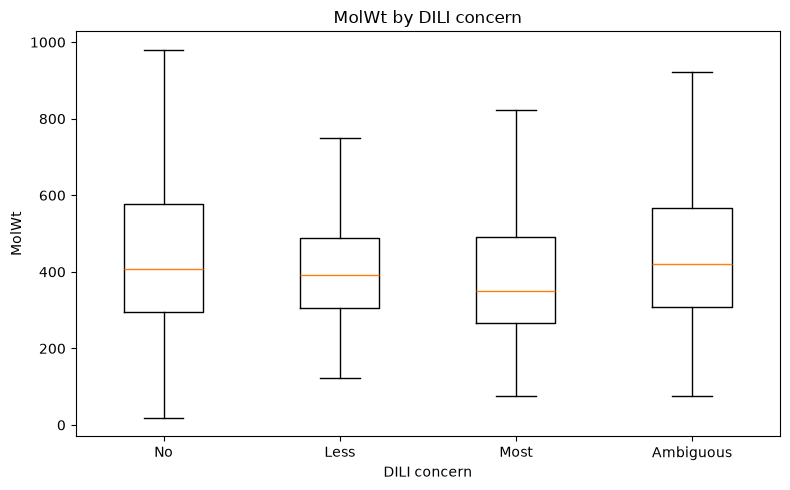

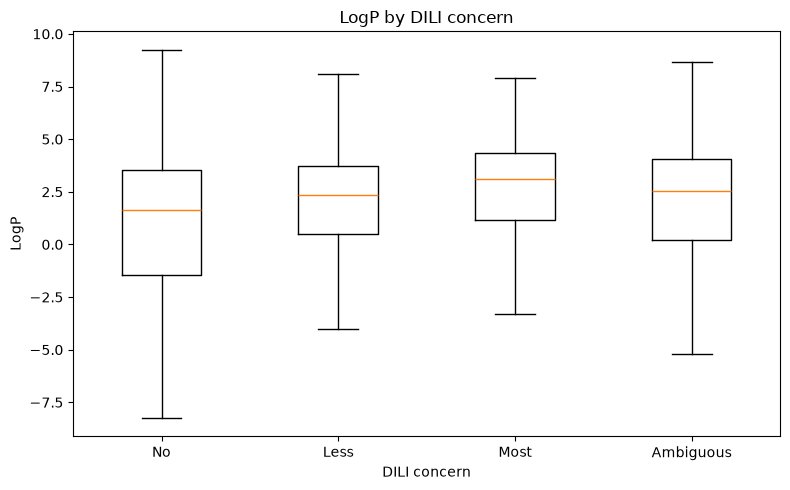

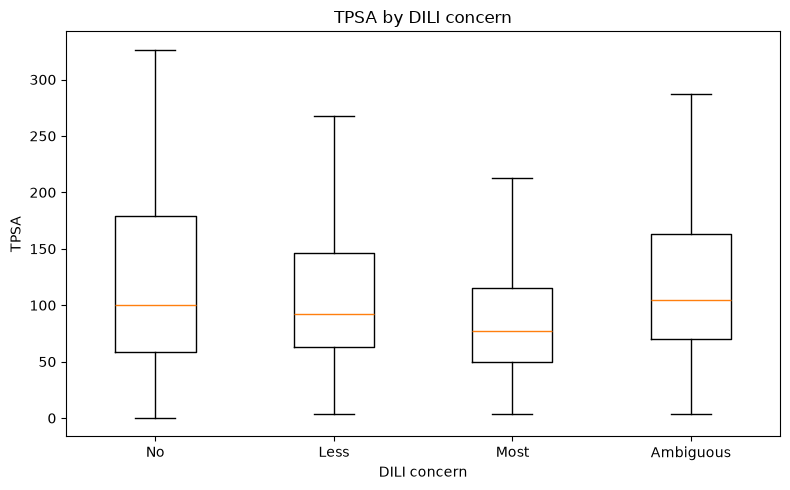

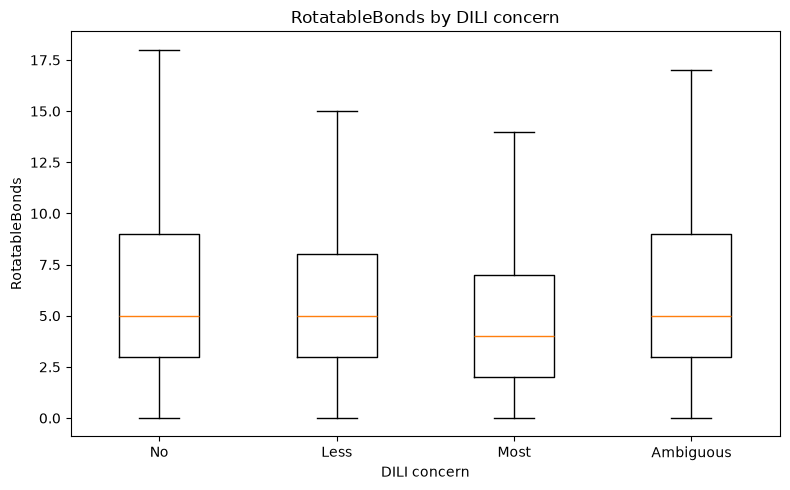

In [13]:
for property_name in ["MolWt", "LogP", "TPSA", "RotatableBonds"]:
    groups, labels = [], []

    for label in concern_order:
        values = eda.loc[eda["ConcernDisplay"] == label, property_name].dropna().to_numpy()
        if len(values):
            groups.append(values)
            labels.append(label)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.boxplot(groups, tick_labels=labels, showfliers=False)
    ax.set_title(f"{property_name} by DILI concern")
    ax.set_xlabel("DILI concern")
    ax.set_ylabel(property_name)

    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"{property_name.lower()}_by_concern.png", dpi=200, bbox_inches="tight")
    plt.show()


## 6. Bemis–Murcko scaffold diversity

In [14]:
def get_murcko_scaffold(smiles):
    if pd.isna(smiles) or not str(smiles).strip():
        return pd.NA

    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return pd.NA

    scaffold = MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol,
        includeChirality=False,
    )

    return scaffold if scaffold else "[ACYCLIC]"

eda["MurckoScaffold"] = eda["SMILES_parent"].apply(get_murcko_scaffold)

scaffold_counts = eda["MurckoScaffold"].value_counts(dropna=False)

scaffold_summary = pd.Series({
    "Unique scaffolds": eda["MurckoScaffold"].nunique(dropna=True),
    "Singleton scaffolds": int((scaffold_counts == 1).sum()),
    "Scaffolds with >=2 compounds": int((scaffold_counts >= 2).sum()),
    "Largest scaffold group": int(scaffold_counts.max()),
    "Acyclic compounds": int((eda["MurckoScaffold"] == "[ACYCLIC]").sum()),
}, name="count")

display(scaffold_summary.to_frame())


,count
Unique scaffolds,785
Singleton scaffolds,658
Scaffolds with >=2 compounds,127
Largest scaffold group,89
Acyclic compounds,82


In [15]:
top_scaffolds = (
    scaffold_counts
    .head(20)
    .rename_axis("MurckoScaffold")
    .to_frame("count")
)

display(top_scaffolds)


,count
MurckoScaffold,
c1ccccc1,89
[ACYCLIC],82
O=C1C=C2CCC3C4CCCC4CCC3C2CC1,11
c1ccncc1,10
c1ccc(Cc2ccccc2)cc1,9
C1=CC(c2ccccc2)C=CN1,7
c1ccc(Cc2ccccn2)cc1,7
c1c[nH]cn1,7
O=C1CN=C(c2ccccc2)c2ccccc2N1,7


In [16]:
scaffold_label_counts = (
    eda.groupby("MurckoScaffold")["ConcernDisplay"]
    .nunique()
    .rename("n_concern_labels")
)

display(
    scaffold_label_counts
    .value_counts()
    .sort_index()
    .rename_axis("Number of concern labels in scaffold")
    .to_frame("Number of scaffolds")
)


,Number of scaffolds
Number of concern labels in scaffold,
1,709
2,51
3,16
4,9


In [17]:
shared_scaffolds = scaffold_label_counts[scaffold_label_counts > 1].index

shared_scaffold_examples = (
    eda.loc[
        eda["MurckoScaffold"].isin(shared_scaffolds),
        ["CompoundName", "ConcernDisplay", "MurckoScaffold"],
    ]
    .sort_values(["MurckoScaffold", "ConcernDisplay", "CompoundName"])
)

print(f"Scaffolds spanning more than one DILI-concern category: {len(shared_scaffolds)}")
display(shared_scaffold_examples.head(50))


Scaffolds spanning more than one DILI-concern category: 76


,CompoundName,ConcernDisplay,MurckoScaffold
1128,Toremifene citrate,Ambiguous,C(=C(c1ccccc1)c1ccccc1)c1ccccc1
245,Clomiphene citrate,Less,C(=C(c1ccccc1)c1ccccc1)c1ccccc1
1069,Tamoxifen citrate,Most,C(=C(c1ccccc1)c1ccccc1)c1ccccc1
827,Ospemifene,No,C(=C(c1ccccc1)c1ccccc1)c1ccccc1
625,Levamlodipine maleate,Ambiguous,C1=CC(c2ccccc2)C=CN1
790,Nimodipine,Ambiguous,C1=CC(c2ccccc2)C=CN1
794,Nisoldipine,Ambiguous,C1=CC(c2ccccc2)C=CN1
54,Amlodipine besylate,Less,C1=CC(c2ccccc2)C=CN1
444,Felodipine,Less,C1=CC(c2ccccc2)C=CN1
785,Nifedipine,Less,C1=CC(c2ccccc2)C=CN1


## 7. Morgan-fingerprint similarity

Morgan fingerprints are used here only for exploratory similarity analysis. The formal modelling fingerprints will be generated in Notebook 03.


In [18]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048,
)

mols = [Chem.MolFromSmiles(smiles) for smiles in eda["SMILES_standardized"]]

fingerprints = [
    morgan_generator.GetFingerprint(mol) if mol is not None else None
    for mol in mols
]

print(f"Fingerprints generated: {sum(fp is not None for fp in fingerprints)} / {len(fingerprints)}")


Fingerprints generated: 1215 / 1215


[13:47:00] WARNING: not removing hydrogen atom without neighbors


In [19]:
nearest_similarity = np.full(len(eda), np.nan)
nearest_index = np.full(len(eda), -1, dtype=int)

valid_indices = [i for i, fp in enumerate(fingerprints) if fp is not None]

for position, i in enumerate(valid_indices):
    candidate_indices = valid_indices[:position] + valid_indices[position + 1:]
    candidate_fps = [fingerprints[j] for j in candidate_indices]

    if not candidate_fps:
        continue

    similarities = DataStructs.BulkTanimotoSimilarity(
        fingerprints[i],
        candidate_fps,
    )

    best_position = int(np.argmax(similarities))
    nearest_similarity[i] = similarities[best_position]
    nearest_index[i] = candidate_indices[best_position]

eda["NearestNeighborSimilarity"] = nearest_similarity
eda["NearestNeighborConcern"] = [
    eda.iloc[j]["ConcernDisplay"] if j >= 0 else pd.NA
    for j in nearest_index
]
eda["NearestNeighborName"] = [
    eda.iloc[j]["CompoundName"] if j >= 0 else pd.NA
    for j in nearest_index
]

display(
    eda[
        [
            "CompoundName",
            "ConcernDisplay",
            "NearestNeighborName",
            "NearestNeighborConcern",
            "NearestNeighborSimilarity",
        ]
    ]
    .sort_values("NearestNeighborSimilarity", ascending=False)
    .head(20)
)


,CompoundName,ConcernDisplay,NearestNeighborName,NearestNeighborConcern,NearestNeighborSimilarity
78,Armodafinil,Ambiguous,Modafinil,Less,1.0
58,Amphetamine sulfate,Less,Dextroamphetamine sulfate,No,1.0
667,Mannitol,No,Sorbitol,No,1.0
629,Levofloxacin,Most,Ofloxacin,Less,1.0
587,Isotretinoin,Most,Tretinoin,Less,1.0
609,Lansoprazole,Less,Dexlansoprazole,Less,1.0
715,Methylphenidate hydrochloride,Less,Dexmethylphenidate hydrochloride,Less,1.0
628,Levocetirizine dihydrochloride,Less,Cetirizine hydrochloride,Less,1.0
810,Ofloxacin,Less,Levofloxacin,Most,1.0
146,Brompheniramine maleate,No,Dexbrompheniramine maleate,No,1.0


In [20]:
similarity_summary = (
    eda.groupby("ConcernDisplay")["NearestNeighborSimilarity"]
    .describe()
    .reindex([x for x in concern_order if x in set(eda["ConcernDisplay"])])
)

display(similarity_summary)


,count,mean,std,min,25%,50%,75%,max
ConcernDisplay,,,,,,,,
No,350.0,0.492139,0.213838,0.095238,0.312658,0.455214,0.644158,1.0
Less,330.0,0.520749,0.208609,0.108108,0.340431,0.493333,0.666667,1.0
Most,206.0,0.435063,0.172765,0.181818,0.286401,0.400000,0.542560,1.0
Ambiguous,329.0,0.449854,0.207267,0.142857,0.273504,0.396226,0.617021,1.0


In [21]:
eda["NearestNeighborSameConcern"] = (
    eda["ConcernDisplay"] == eda["NearestNeighborConcern"]
)

neighbor_agreement = (
    eda.groupby("ConcernDisplay")["NearestNeighborSameConcern"]
    .mean()
    .mul(100)
    .rename("nearest_neighbor_same_concern_pct")
    .reindex([x for x in concern_order if x in set(eda["ConcernDisplay"])])
)

display(neighbor_agreement.to_frame().round(1))


,nearest_neighbor_same_concern_pct
ConcernDisplay,
No,50.3
Less,45.8
Most,32.5
Ambiguous,29.8


## 8. PCA chemical-space visualization

PCA is applied to the small continuous property set above to obtain a simple, reproducible chemical-space view.

This is exploratory only; visual overlap or separation is not a measure of predictive performance.


In [22]:
pca_input = eda[property_columns].copy()
pca_input = pca_input.fillna(pca_input.median(numeric_only=True))

X_scaled = StandardScaler().fit_transform(pca_input)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

eda["PCA1"] = X_pca[:, 0]
eda["PCA2"] = X_pca[:, 1]

print(
    f"PC1 explained variance: {pca.explained_variance_ratio_[0]:.3f}"
)
print(
    f"PC2 explained variance: {pca.explained_variance_ratio_[1]:.3f}"
)
print(
    f"Total explained variance: {pca.explained_variance_ratio_[:2].sum():.3f}"
)


PC1 explained variance: 0.792
PC2 explained variance: 0.125
Total explained variance: 0.917


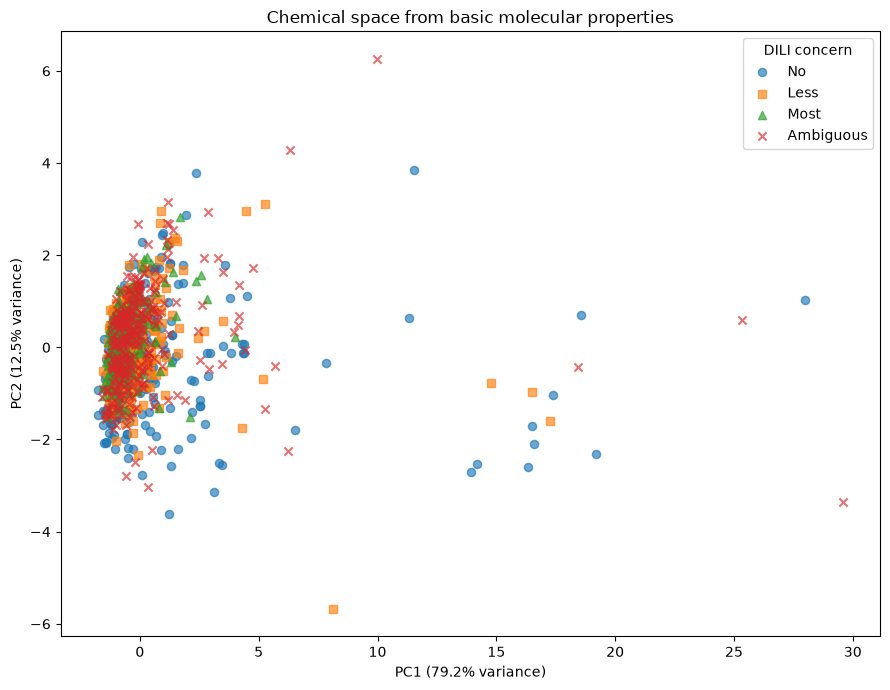

In [23]:
fig, ax = plt.subplots(figsize=(9, 7))
markers = ["o", "s", "^", "x", "D", "P"]

for marker, label in zip(markers, concern_order):
    subset = eda.loc[eda["ConcernDisplay"] == label]

    ax.scatter(
        subset["PCA1"],
        subset["PCA2"],
        label=label,
        marker=marker,
        alpha=0.65,
        s=35,
    )

ax.set_title("Chemical space from basic molecular properties")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
ax.legend(title="DILI concern")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "pca_chemical_space.png", dpi=200, bbox_inches="tight")
plt.show()


## 9. Ambiguous compounds

In [24]:
if "Ambiguous" in set(eda["ConcernDisplay"]):
    ambiguous = eda.loc[
        eda["ConcernDisplay"] == "Ambiguous",
        [
            "LTKBID",
            "CompoundName",
            "MolWt",
            "LogP",
            "TPSA",
            "MurckoScaffold",
            "NearestNeighborName",
            "NearestNeighborConcern",
            "NearestNeighborSimilarity",
            "PCA1",
            "PCA2",
        ],
    ].copy()

    print(f"Ambiguous compounds: {len(ambiguous)}")
    display(ambiguous.head(20))
else:
    print("No Ambiguous compounds were found.")


Ambiguous compounds: 329


,LTKBID,CompoundName,MolWt,LogP,TPSA,MurckoScaffold,NearestNeighborName,NearestNeighborConcern,NearestNeighborSimilarity,PCA1,PCA2
4,LT03614,Acalabrutinib,465.517,3.31260,118.51,O=C(Nc1ccccn1)c1ccc(-c2nc(C3CCCN3)n3ccncc23)cc1,Piroxicam,Less,0.282353,-0.248439,0.899895
11,LT00913,Acetohydroxamic acid,75.067,-0.48830,49.33,[ACYCLIC],Hydroxyurea,Most,0.428571,-1.470518,-1.426001
18,LT02889,Afatinib dimaleate,718.091,3.81350,237.81,c1ccc(Nc2ncnc3cc(OC4CCOC4)ccc23)cc1,Dacomitinib,Less,0.576087,0.755571,0.585275
24,LT03620,Alectinib hydrochloride,519.089,5.19508,72.36,O=C1c2ccc(N3CCC(N4CCOCC4)CC3)cc2Cc2[nH]c3ccccc3c21,Gilteritinib fumarate,Ambiguous,0.245614,-0.389087,1.530499
31,LT02888,Alogliptin benzoate,461.522,1.77928,134.35,O=c1cc(N2CCCCC2)n(Cc2ccccc2)c(=O)[nH]1,Linagliptin,Less,0.362637,-0.246665,0.354590
36,LT00502,Altretamine,210.285,0.06960,48.39,c1ncncn1,Mechlorethamine hydrochloride,Ambiguous,0.142857,-1.056922,-0.942472
38,LT00503,Amantadine hydrochloride,187.714,2.33570,26.02,C1C2CC3CC1CC(C2)C3,Memantine hydrochloride,Less,0.478261,-1.231029,0.369953
40,LT00618,Ambrisentan,378.428,3.51564,81.54,c1ccc(C(COc2ncccn2)c2ccccc2)cc1,Naproxen,Less,0.269231,-0.656136,0.211132
42,LT03895,Amifampridine phosphate,207.126,-0.68260,142.69,c1ccncc1,Amifampridine,No,0.727273,-0.812593,-1.127535
56,LT00256,Amoxapine,313.788,3.42920,36.86,c1ccc2c(c1)N=C(N1CCNCC1)c1ccccc1O2,Loxapine succinate,Ambiguous,0.618182,-0.948217,0.558204


In [25]:
if "Ambiguous" in set(eda["ConcernDisplay"]):
    ambiguous_neighbors = (
        ambiguous["NearestNeighborConcern"]
        .value_counts(dropna=False)
        .rename_axis("Nearest-neighbor concern")
        .to_frame("count")
    )

    display(ambiguous_neighbors)


,count
Nearest-neighbor concern,
Less,101
Ambiguous,98
No,75
Most,55


## 10. SeverityClass as a prediction target

The previous sections showed that `SeverityClass` is strongly related to `vDILI-Concern`, but it may also be useful as a **separate ordinal prediction endpoint**.

Here we examine:

- how many compounds belong to each severity level;
- whether all levels are sufficiently represented;
- whether basic molecular properties show monotonic trends with severity;
- where severity levels lie in the basic-property PCA space.

This section does **not** use SeverityClass as an input feature.

,count,percentage
SeverityClass,,
0,394,32.43
1,3,0.25
2,46,3.79
3,375,30.86
4,91,7.49
5,69,5.68
6,6,0.49
7,60,4.94
8,171,14.07


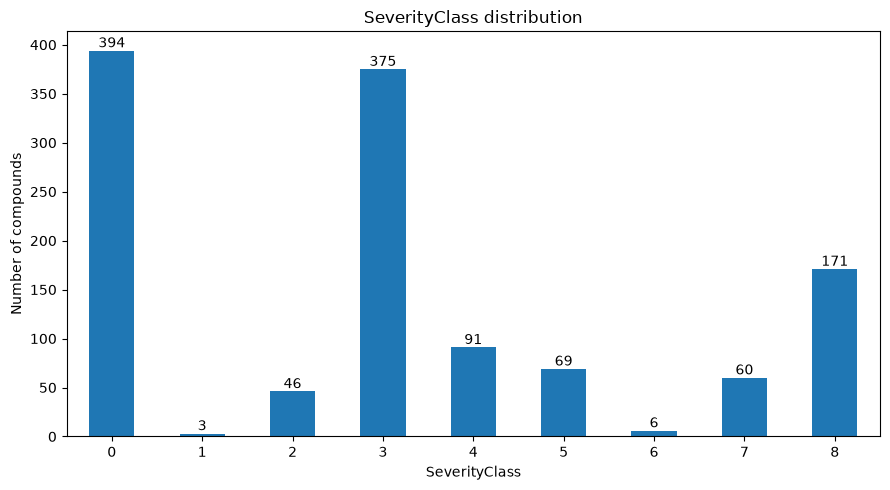

In [26]:
severity_order = sorted(
    pd.Series(eda["SeverityClass"].dropna().unique())
    .astype(int)
    .tolist()
)

severity_distribution = (
    eda["SeverityClass"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("SeverityClass")
    .to_frame("count")
)

severity_distribution["percentage"] = (
    100 * severity_distribution["count"] / len(eda)
)

display(severity_distribution.round(2))

fig, ax = plt.subplots(figsize=(9, 5))

severity_distribution.loc[
    severity_distribution.index.notna(),
    "count"
].plot(kind="bar", ax=ax)

ax.set_title("SeverityClass distribution")
ax.set_xlabel("SeverityClass")
ax.set_ylabel("Number of compounds")
ax.tick_params(axis="x", rotation=0)

for i, value in enumerate(
    severity_distribution.loc[
        severity_distribution.index.notna(),
        "count"
    ].values
):
    ax.text(i, value, str(int(value)), ha="center", va="bottom")

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "severity_class_distribution.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


In [27]:
severity_property_medians = (
    eda.groupby("SeverityClass")[property_columns]
    .median()
    .sort_index()
)

display(severity_property_medians.round(2))


,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,HeavyAtoms,RingCount
SeverityClass,,,,,,,,
0,407.16,1.74,99.08,2.0,5.0,5.0,28.0,3.0
1,372.42,-0.05,76.10,0.0,4.0,2.0,25.0,4.0
2,335.03,1.84,84.78,2.0,4.0,3.5,22.0,2.0
3,412.02,2.21,102.26,2.0,5.0,5.0,28.0,3.0
4,459.51,3.27,103.37,2.0,6.0,5.0,31.0,4.0
5,365.84,2.52,83.58,2.0,5.0,5.0,25.0,3.0
6,272.28,-1.14,93.22,3.0,5.0,4.5,17.5,1.0
7,390.62,3.04,104.39,2.0,5.0,5.0,26.5,3.0
8,351.32,3.00,76.72,2.0,4.0,4.0,24.0,3.0


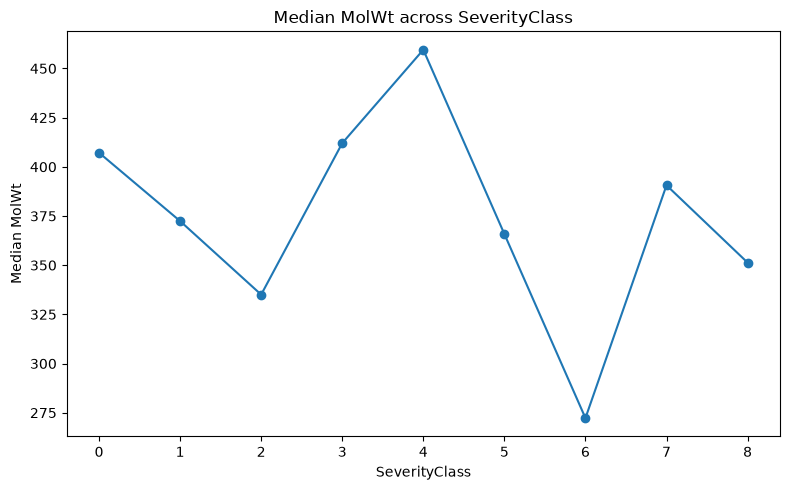

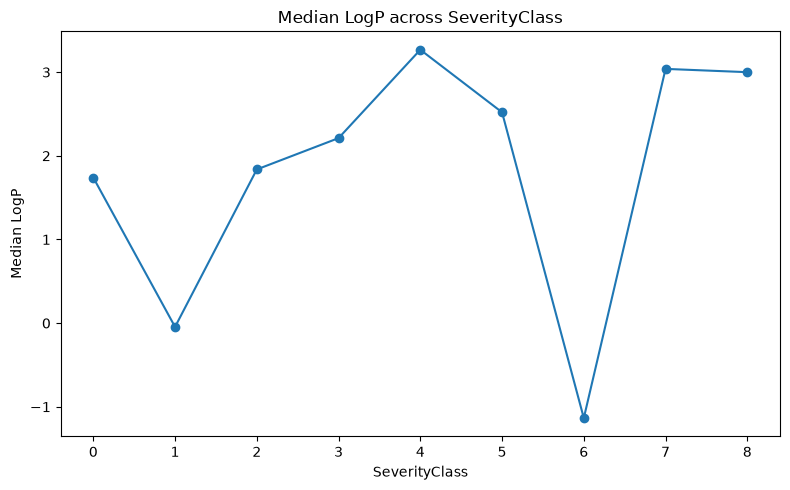

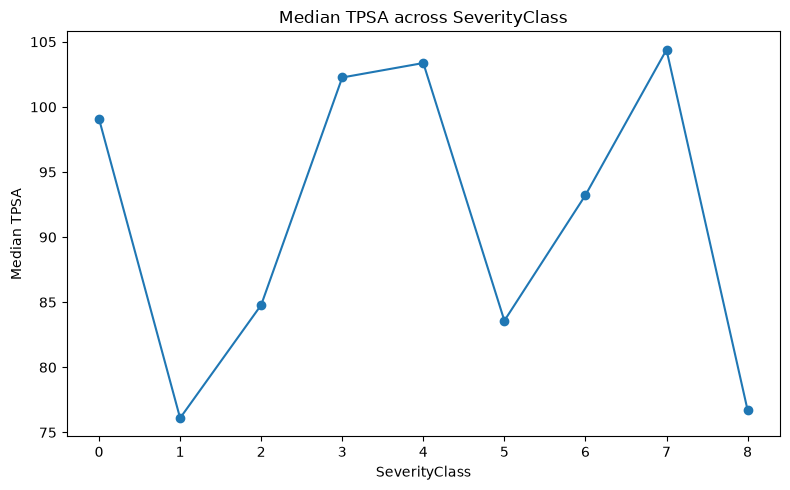

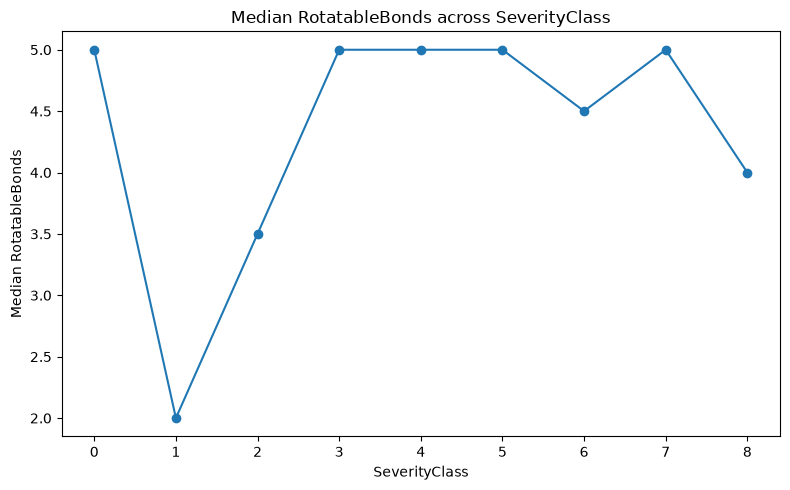

In [28]:
# Visualize median trends across the ordered severity scale.
for property_name in ["MolWt", "LogP", "TPSA", "RotatableBonds"]:
    trend = severity_property_medians[property_name]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(
        trend.index.astype(int),
        trend.values,
        marker="o",
    )

    ax.set_title(f"Median {property_name} across SeverityClass")
    ax.set_xlabel("SeverityClass")
    ax.set_ylabel(f"Median {property_name}")
    ax.set_xticks(severity_order)

    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / f"{property_name.lower()}_severity_trend.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


In [29]:
# Spearman correlation is used only as a descriptive summary of monotonic trends.
severity_spearman = (
    eda[property_columns + ["SeverityClass"]]
    .corr(method="spearman")["SeverityClass"]
    .drop("SeverityClass")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename("spearman_rho")
    .to_frame()
)

display(severity_spearman.round(3))


,spearman_rho
LogP,0.178
HBD,-0.091
TPSA,-0.080
RotatableBonds,-0.064
MolWt,-0.060
HBA,-0.058
RingCount,0.048
HeavyAtoms,-0.045


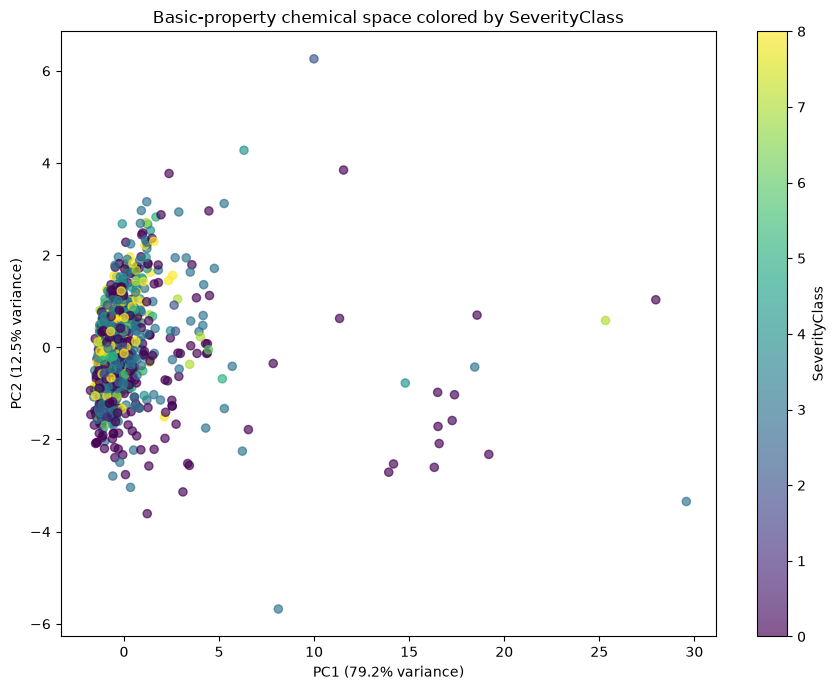

In [30]:
# Reuse the PCA coordinates from the basic molecular-property space,
# but color them by the ordered SeverityClass target.
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    eda["PCA1"],
    eda["PCA2"],
    c=eda["SeverityClass"].astype(float),
    cmap="viridis",
    alpha=0.65,
    s=35,
)

ax.set_title("Basic-property chemical space colored by SeverityClass")
ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)
ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("SeverityClass")
cbar.set_ticks(severity_order)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "pca_chemical_space_severity.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


In [31]:
# A direct 0–8 classification experiment needs enough observations
# in every class to support the planned cross-validation scheme.
SEVERITY_REQUIRED_OUTER_FOLDS = 5

severity_nonmissing = eda.dropna(subset=["SeverityClass"]).copy()
severity_nonmissing["SeverityClass"] = severity_nonmissing["SeverityClass"].astype(int)

severity_counts_for_cv = (
    severity_nonmissing["SeverityClass"]
    .value_counts()
    .sort_index()
)

minimum_severity_count = int(severity_counts_for_cv.min())

print(f"SeverityClass observations: {len(severity_nonmissing)}")
print(f"Smallest severity class: {minimum_severity_count} compounds")
print(f"Planned outer CV folds: {SEVERITY_REQUIRED_OUTER_FOLDS}")

if minimum_severity_count < SEVERITY_REQUIRED_OUTER_FOLDS:
    sparse_levels = severity_counts_for_cv[
        severity_counts_for_cv < SEVERITY_REQUIRED_OUTER_FOLDS
    ]

    print()
    print("Direct 9-class 5-fold CV is NOT appropriate with the current distribution.")
    print("Severity levels with fewer observations than folds:")
    display(sparse_levels.to_frame("count"))
else:
    print("The raw class counts are sufficient for a 5-fold severity experiment.")


SeverityClass observations: 1215
Smallest severity class: 3 compounds
Planned outer CV folds: 5

Direct 9-class 5-fold CV is NOT appropriate with the current distribution.
Severity levels with fewer observations than folds:


,count
SeverityClass,
1,3


### Severity-target interpretation

The feature trends and PCA above help determine whether molecular chemistry changes gradually with `SeverityClass`.

However, class distribution is also a modelling constraint. If one or more severity levels contain fewer observations than the intended number of folds, we should **not** force a direct 9-class cross-validation experiment.

Notebook 03 therefore saves the SeverityClass target population and performs a formal sample/group feasibility check before creating any severity folds.

## 11. EDA summary

In [32]:
summary = pd.Series({
    "Compounds": len(eda),
    "DILI-concern categories": eda["ConcernDisplay"].nunique(dropna=True),
    "Unique Murcko scaffolds": eda["MurckoScaffold"].nunique(dropna=True),
    "Singleton scaffolds": int((scaffold_counts == 1).sum()),
    "Multi-fragment compounds": int((eda["n_fragments"].fillna(0) > 1).sum()),
    "Unique standardized structures": eda["InChIKey_standardized"].nunique(dropna=True),
    "Unique parent structures": eda["InChIKey_parent"].nunique(dropna=True),
}, name="value")

display(summary.to_frame())

print("\nDILI-concern distribution:")
display(
    eda["ConcernDisplay"]
    .value_counts()
    .reindex(concern_order)
    .to_frame("count")
)

print("\nMedian molecular properties by DILI concern:")
display(property_by_concern.round(2))


,value
Compounds,1215
DILI-concern categories,4
Unique Murcko scaffolds,785
Singleton scaffolds,658
Multi-fragment compounds,560
Unique standardized structures,1214
Unique parent structures,1204



DILI-concern distribution:


,count
ConcernDisplay,
No,350
Less,330
Most,206
Ambiguous,329



Median molecular properties by DILI concern:


,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,HeavyAtoms,RingCount
ConcernDisplay,,,,,,,,
No,408.17,1.62,99.96,2.0,5.0,5.0,28.0,3.0
Less,391.99,2.33,91.84,2.0,5.0,5.0,27.0,3.0
Most,350.32,3.12,77.60,2.0,4.0,4.0,24.0,3.0
Ambiguous,421.31,2.53,104.55,2.0,6.0,5.0,29.0,3.0


## Notebook Complete

This notebook now describes both candidate endpoints:

1. `vDILI-Concern` — the primary No / Less / Most benchmark target;
2. `SeverityClass` — a separate ordered 0–8 endpoint whose feasibility depends on its class distribution.

It also retains Ambiguous compounds throughout the exploratory analysis.

Next, `03_features_and_splits.ipynb` will inspect the actual RDKit-descriptor and Morgan-fingerprint feature spaces, freeze the main concern folds, and evaluate whether a valid severity cross-validation design can be created without artificially merging severity levels.
